<table style="border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:middle; width:500px;">
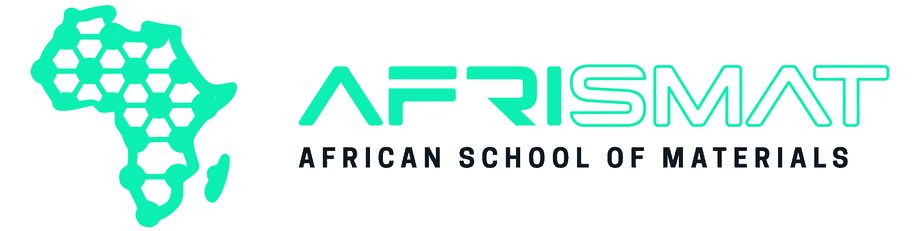
</td>
<td style="border:none; vertical-align:middle;">

# **A-IDI: Africa Inclusive Digital Industries 2026**
> ## **Circular Mechatronics 4 Africa (CM4A)**
> ### **Introduction to robotics online lab exercise 2**

</td>
</tr></table>


# **Flying a Quadrotor with Nonlinear Model Predictive Control**
> ### **Build the controller yourself, one piece at a time**

A small multirotor must fly to a treatment point over a field. Something solid is in the way.

**In this workshop you will build a controller similar to the one in the video after the setup cell: it flies a quadrotor over the obstruction to the treatment point.**

The four rotors can only **push**. There is no sideways force, so to move across the field the vehicle must tilt first.

Change only the cells you are asked to: the task cells, the answer cells under each **Explain**, and the lines marked `EDIT`. The rest are locked, so that nothing can be changed by accident. If something stops working, open a fresh copy from the link in the README.

**Do the mobile robot notebook first.** This one uses the same method and the same code structure, and does not explain them again. You write the parts that are new: the equations of motion, the cost, and the loop. Three tasks have a check that must print **PASS**; two tasks marked **Explain** ask for a sentence or two, which you write in the cell below the question before opening the answer.

## **0. Setting up**

Run this cell. It should finish by printing `ready`.

In [ ]:
%pip install -q mujoco casadi "imageio[ffmpeg]"

import os, sys, urllib.request

LIBRARY = "drone_lab.py"
REPO = "https://raw.githubusercontent.com/JohnEkD/nmpc-workshop/main/"

# the workshop code lives in the lib folder beside this notebook; anything
# missing is downloaded from the repository
os.makedirs("lib", exist_ok=True)
in_colab = os.path.isdir("/content")          # on Colab, always take a fresh copy
for name in (LIBRARY, "common.py"):
    path = os.path.join("lib", name)
    if in_colab or not os.path.exists(path):
        try:
            urllib.request.urlretrieve(REPO + "lib/" + name, path)
        except Exception:
            if os.path.exists(path):
                pass                          # keep the copy already here
            else:
                raise FileNotFoundError(
                    path + " was not found. Put " + name + " in a folder named "
                    "lib beside this notebook (in Colab, use the folder icon on "
                    "the left), then run this cell again.") from None

sys.path.insert(0, os.path.abspath("lib"))
import numpy as np
import casadi as ca
import matplotlib.pyplot as plt
import drone_lab as lab       # on Colab, this also sets up MuJoCo's 3-D rendering

lab.fetch_model()
print("ready")

### **Build a controller similar to this**

Run the next cell to watch the finished controller at work. It plays a stored video from the `videos` folder; if that folder is missing, it makes the video instead, which takes about 25 seconds.

1. **Left:** the quadrotor, simulated in MuJoCo, a physics simulator.
2. **Right:** what the controller sees. The dots are its plan for the next second, which it makes again twenty times a second. The orange arrows are the rotor thrusts.

By the end of this notebook, you will have written a controller like this yourself.

In [ ]:
lab.preview()

## **1. The problem**

### **1.1 The application**

A multirotor works over a field as part of a crop-protection task (spraying crops against pests and disease). It must fly from a start point to a treatment point while keeping clear of a fixed obstruction such as a mast or a tree.

Rotary-wing aircraft are established tools in precision agriculture for targeted spraying, and keeping clear of obstructions is a routine requirement [1].

**The control problem.** At every instant, choose the thrust of each of the two rotor pairs so that the vehicle reaches the treatment point, stays within its thrust and tilt limits, and keeps clear of the obstruction.

### **1.2 The system to be controlled**

The vehicle is a Skydio X2 as distributed in the DeepMind MuJoCo Menagerie [6], simulated by MuJoCo [5]. This is the model itself.

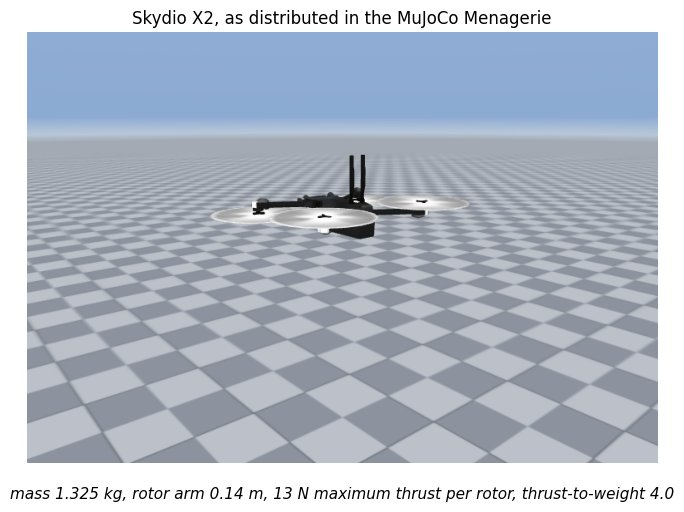

In [ ]:
facts = lab.vehicle_facts()
print("mass              %.4f kg" % facts["mass"])
print("weight            %.3f N" % facts["weight"])
print("pitch inertia Iyy %.6f kg m^2" % facts["Iyy"])
print("rotor arm L       %.3f m" % facts["arm"])
print("max thrust        %.1f N per rotor, so thrust/weight = %.2f"
      % (facts["tmax"], 4 * facts["tmax"] / facts["weight"]))
print("thrust to hover   %.4f N per pair" % lab.hover_thrust())

**Thrust** is the upward push of a rotor, in newtons. The vehicle weighs 13 N and its four rotors can push up to 52 N together, a **thrust-to-weight ratio** of four: there is ample thrust to spare. If the controller fails later, it is the controller failing, not the vehicle.

The airframe can move in six ways (three positions and three rotations: **roll**, **pitch** and **yaw**, turning about the front-to-back, side-to-side and vertical axes). It has four thrusts. The rotors are commanded in two mirrored pairs, a **rear pair** and a **front pair**, as the figure shows. Within a pair the two rotors push equally and spin in opposite directions (cw and ccw: clockwise and anticlockwise), so their turning effects (**moments**) about the other axes cancel. What is left is a vertical force and a pitch moment, so the vehicle moves in one vertical plane.

From here on, $T_{\mathrm{r}}$ is the thrust of the **rear pair** and $T_{\mathrm{f}}$ that of the **front pair**, each between 0 and 26 N. "Thrust to hover" above is per pair: two pairs of 6.5 N hold up 13 N.

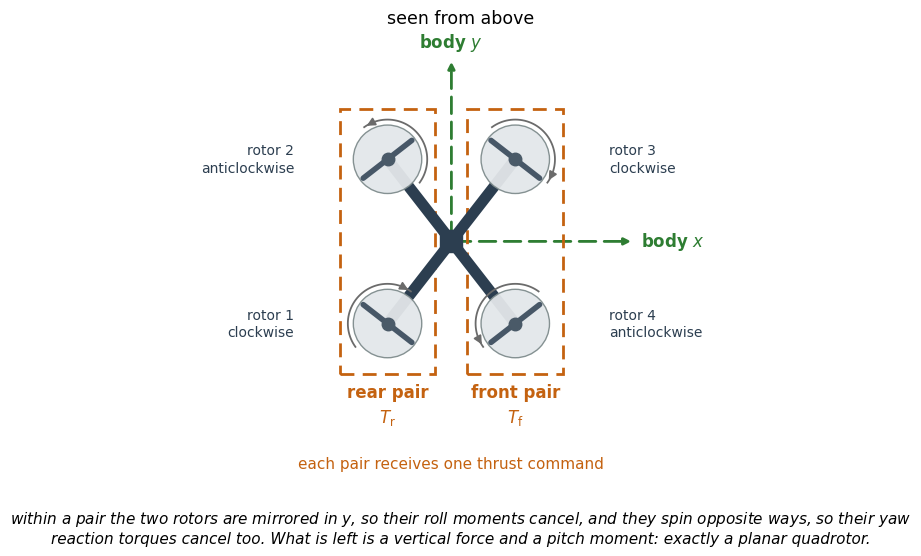

That is a claim, so check it: fly a manoeuvre and measure what leaves the plane.

In [ ]:
import mujoco
hov = lab.hover_thrust()
print("%-16s %11s %11s %11s" % ("case", "y (m)", "roll rate", "yaw rate"))
for label, ur, uf in (("hover", hov, hov),
                      ("pitch forward", hov * 1.05, hov * 0.95),
                      ("pitch back", hov * 0.95, hov * 1.05)):
    m = lab.build_plant(); d = mujoco.MjData(m); mujoco.mj_forward(m, d)
    worst = np.zeros(3)
    for _ in range(int(3.0 / m.opt.timestep)):
        lab.apply_pair(d, ur, uf)
        mujoco.mj_step(m, d)
        worst = np.maximum(worst, np.abs([d.qpos[1], d.qvel[3], d.qvel[5]]))
    print("%-16s %11.2e %11.2e %11.2e" % (label, worst[0], worst[1], worst[2]))

Zero to machine precision (the smallest difference the computer can represent). The reduction to a plane is exact, not an approximation.

So the state is six numbers and the command is two:

$$\mathbf{s} = \begin{bmatrix} x & z & \theta & \dot x & \dot z & \omega \end{bmatrix}^{\top}, \qquad \mathbf{u} = \begin{bmatrix} T_{\mathrm{r}} & T_{\mathrm{f}} \end{bmatrix}^{\top}$$

The $^{\top}$ means the row is stood up as a column. $x$ is the distance across the field and $z$ the height, both in metres; $\theta$ is the **pitch**, the tilt angle; $\dot x$ and $\dot z$ are the two velocities; $\omega$ is the pitch rate, how fast the tilt is changing. (In the robot notebook $\omega$ was the turn rate and a command; here it is part of the state.)

### **1.3 Modelling assumptions**

The assumptions taken in developing the model of this system are provided in the table below.

| # | Assumption | Why it is reasonable |
| --- | --- | --- |
| 1 | Motion stays in the vertical plane | Verified above, to machine precision |
| 2 | The airframe is rigid, its mass constant | No payload or spray system is modelled |
| 3 | Thrust acts along the **body axis** (straight up out of the airframe) and equals the command | Standard at moderate speed [2] |
| 4 | Rotor speed changes instantly | Left out of the model **and** the simulator; a real rotor needs tens of milliseconds [2] |
| 5 | Air resistance (drag) is neglected | The simulator can switch it on; a future workshop shows what it costs |
| 6 | Thrust is between 0 and its maximum | The rotors have fixed blades and cannot push downwards |
| 7 | The state is measured exactly | No **estimator** (a method that works the state out from sensor readings) is modelled |
| 8 | The vehicle is a point | Safe only if the margin covers the airframe. The rotor tips reach 0.27 m from the centre, and the 0.35 m margin covers them. See [Section 1.4](#scrollTo=section-1-4) |

### **1.4 The task**

In [ ]:
print("start (%.1f, %.1f), goal (%.1f, %.1f)"
      % (lab.START[0], lab.START[1], lab.GOAL[0], lab.GOAL[1]))
print("obstruction at (%.1f, %.1f), radius %.2f m, margin %.2f m"
      % (lab.OBS_C[0], lab.OBS_C[1], lab.OBS_R, lab.CLEAR))
print("so the controller must stay %.2f m from its centre"
      % (lab.OBS_R + lab.CLEAR))

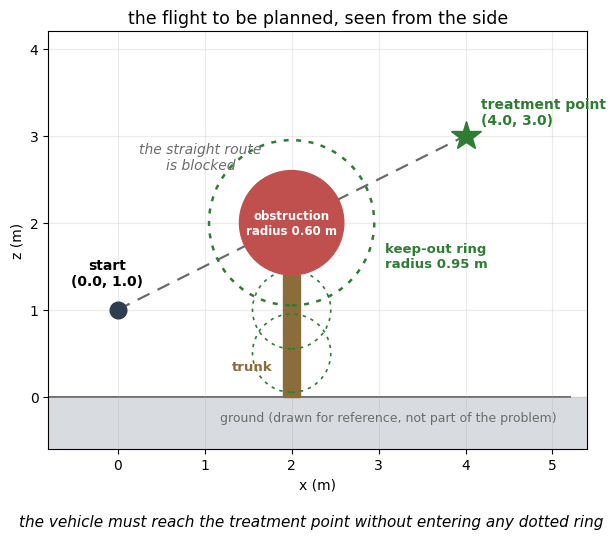

The obstruction stands on a **trunk** that reaches the ground, like a tree or a mast. So the vehicle cannot pass underneath it: it must go over.

The keep-out rings are larger than the obstruction and its trunk, and assumption 8 is the reason. The ground is drawn for reference only: it is not part of the problem.

The figure below is the same scene, close up. The grey line is a flight by the controller you will build in [Section 5](#scrollTo=section-5), flown in MuJoCo; for now, look only at the rings.

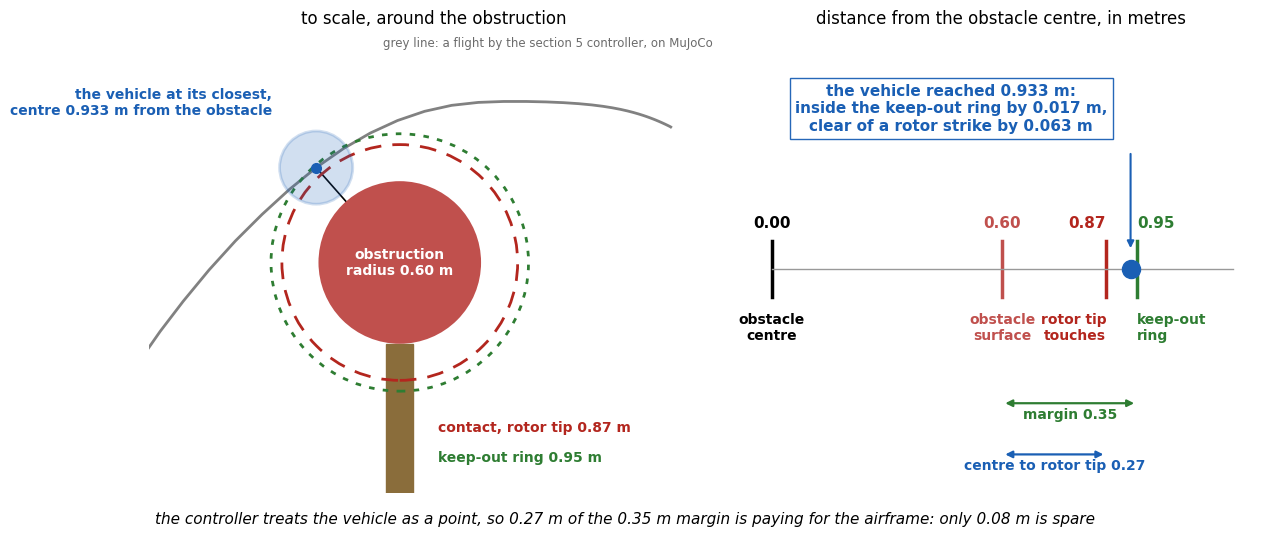

## **2. The model**

### **2.1 What you need to know to fly**

Unlike a ground robot, position alone is not enough. Thrust produces **acceleration**, so the state must carry velocities too. The tilt (the pitch) must be tracked as well, because it decides which way the thrust points.

### **2.2 The model**

This is the vehicle, with the symbols the equations use: mass $m$, arm length $L$ (centre to rotor), pitch **inertia** $I_{yy}$ (how hard the airframe is to spin about its side-to-side axis) and gravity $g$.

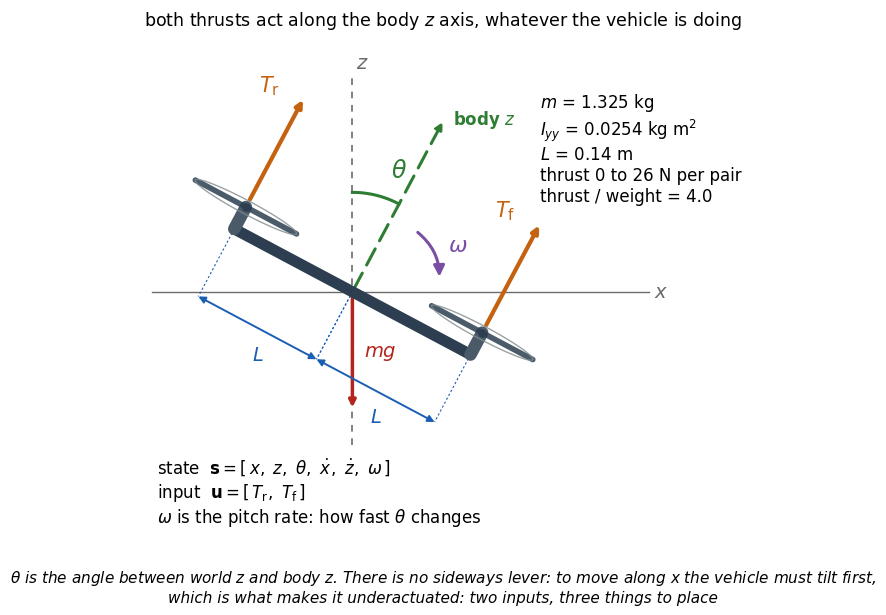

Both thrusts act along the body axis. Resolve that into world axes.

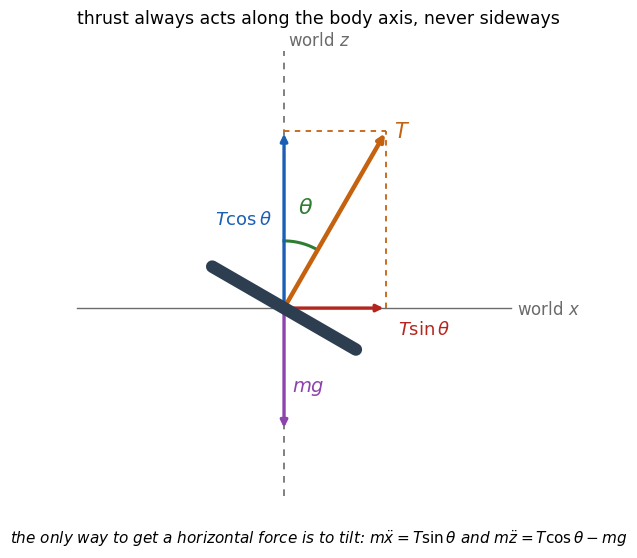

Two dots mean a rate of change taken twice, that is an acceleration: $\ddot x$ is how fast $\dot x$ is changing, in m/s².

Write $T = T_{\mathrm{r}} + T_{\mathrm{f}}$ for the total thrust. Newton's second law (force = mass × acceleration) in each direction, and the same law for turning (moment = inertia × turning acceleration), give

$$\ddot x = \frac{T}{m}\sin\theta, \qquad \ddot z = \frac{T}{m}\cos\theta - g, \qquad \dot\omega = \frac{L\,(T_{\mathrm{r}} - T_{\mathrm{f}})}{I_{yy}}$$

These give the rates of change of the last three states. The first three are simpler: the rate of change of $x$ is the velocity $\dot x$, which is itself the fourth state; likewise for $z$; and the rate of change of $\theta$ is $\omega$.

Three features decide everything that follows.

1. **It is nonlinear**, through $\sin\theta$ and $\cos\theta$.
2. **It is underactuated**: two inputs, three things to place ($x$, $z$ and $\theta$). There is no horizontal force. The vehicle must pitch, accelerate, then pitch back to stop.
3. **The thrusts cannot go negative.** Rotors push one way only.

### **2.3 Could one fixed pair of thrusts do the job?**

Start with the simplest possible answer: **pick one pair of thrusts and hold it**, with the rear pair a little stronger than the front.

### **Explain 1: what will the pitch do?**

Before you look at the next figure: with $T_{\mathrm{r}} - T_{\mathrm{f}}$ held constant, use the third equation of [Section 2.2](#scrollTo=section-2-2) to say whether the pitch rate $\omega$ stays constant or keeps growing.

*Your answer:*

<details>
<summary>Answer</summary>

It keeps growing. A constant difference makes $\dot\omega$ constant: that is a constant pitch **acceleration**, so $\omega$ rises steadily and the pitch curves upwards ever faster.
</details>

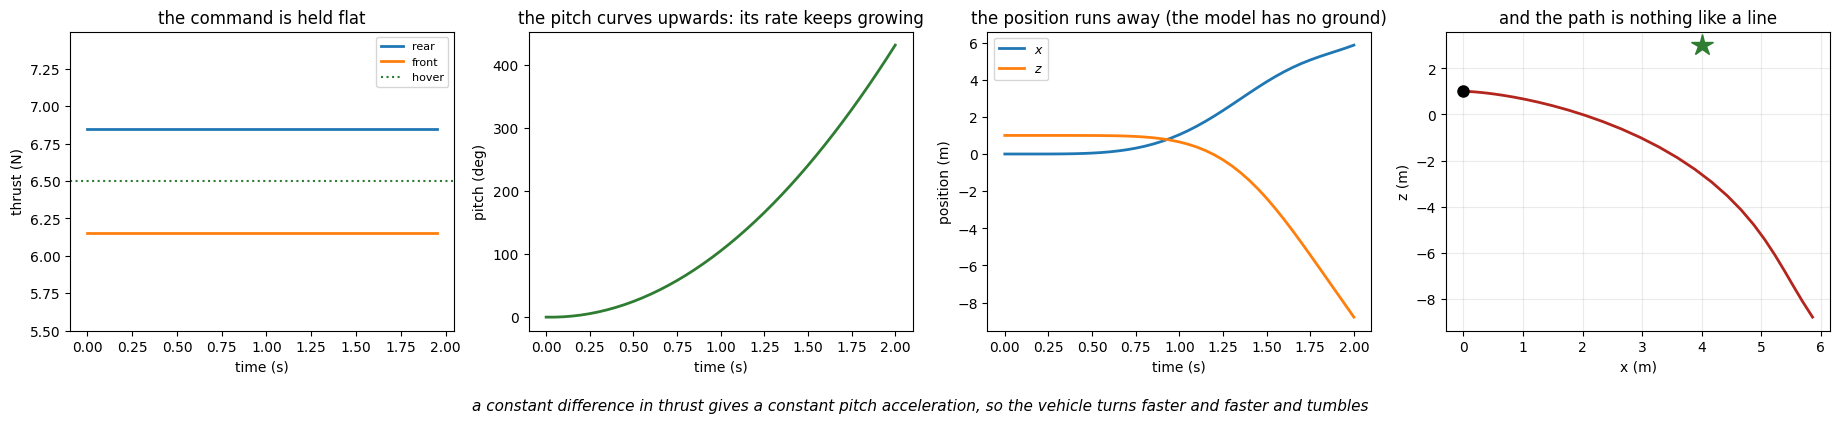

It fails. The pitch rate keeps growing, so the vehicle tips over and tumbles, and the position runs away. It falls far below where the ground would be, because the model has no ground. Equal thrusts would not help either: they only hover, or move straight up or down, never across.

So the thrusts must **change as the flight goes on**: a different pair at every step. At 20 steps a second over one second that is forty numbers to choose, and each one affects everything that follows. As in the robot notebook, that is an **optimisation problem**.

## **3. The approach, and the algorithm**

### **3.0 The method**

The control problem from [Section 1.1](#scrollTo=section-1-1) has four parts:

1. reach a point the vehicle cannot fly straight to,
2. respect the thrust limits,
3. keep the pitch within bounds,
4. keep clear of the obstruction and its trunk.

The method is the one from the robot notebook: **choose the thrusts by solving an optimisation problem over a short window of the future, apply only the first pair, then solve again.** That is nonlinear model predictive control.

### **3.1 Answers on the boundary**

The robot notebook (Section 3.1) showed that the best allowed answer can sit exactly on a constraint. Here that happens to the thrust, which often **saturates**: it sits exactly on its limit of 0 or 26 N.

### **3.2 Cost, and what the weights mean**

The controller is told what a good flight is with a **cost**. Four things can be wrong with the state, and using thrust has a price of its own.

$$\underbrace{w_p\big(e_x^2 + e_z^2\big)}_{\textbf{wrong place}} + \underbrace{w_\theta\,e_\theta^2}_{\textbf{wrong tilt}} + \underbrace{w_v\big(e_{\dot x}^2 + e_{\dot z}^2\big)}_{\textbf{still moving}} + \underbrace{w_\omega\,e_\omega^2}_{\textbf{still turning}} \;+\; \underbrace{w_T \lVert \Delta\mathbf{u}_k \rVert^2}_{\textbf{using thrust}}$$

Each $e$ is one part of the **error**: the state minus the goal state. The goal state is $(4, 3, 0, 0, 0, 0)$: at the treatment point, level, and not moving.

Thrust is measured from **hover**, not from zero: $\Delta\mathbf{u}_k = \mathbf{u}_k - u_{\mathrm{hover}}$, where $u_{\mathrm{hover}} = 6.5$ N is the thrust per pair that holds the vehicle still. Measured from zero, the controller would learn that switching the motors off is cheap.

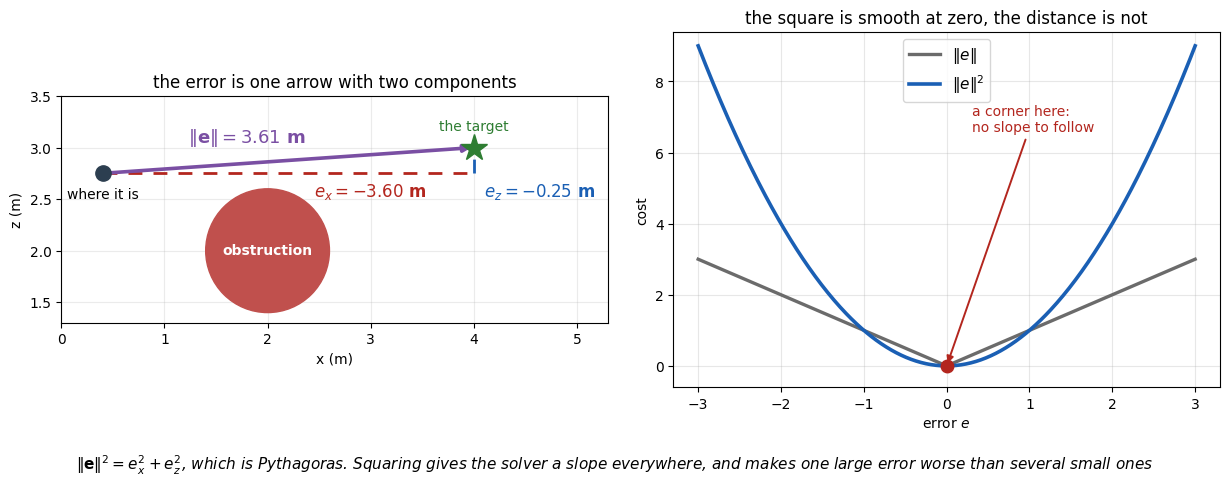

### **3.2b Names for the pieces**

Only what is new since the robot notebook.

| symbol | meaning | in code |
| --- | --- | --- |
| $e_x$ to $e_\omega$ | the six parts of the error: $e_x, e_z, e_\theta, e_{\dot x}, e_{\dot z}, e_\omega$ | `e[0]` to `e[5]` |
| $\mathbf{e}_k$ | all six together, at step $k$ | `X[:, k] - goal` |
| $\ell^{\text{state}}$ | the first four terms above, $\ell^{\text{state}}(\mathbf{e})$: the cost of the state alone | `my_state_cost` |
| $\ell$ | the cost of one step, $\ell(\mathbf{e}_k, \Delta\mathbf{u}_k)$: $\ell^{\text{state}}$ plus the thrust term | `my_stage_cost` |
| $V_f$ | the cost of the last step: $w_{\mathrm{term}}\,\ell^{\text{state}}(\mathbf{e}_N)$ | `my_terminal_cost` |
| $J$ | the cost of the whole plan | `my_total_cost` |
| $w_p$ to $w_{\mathrm{term}}$ | the weights: $w_p, w_\theta, w_v, w_\omega, w_T$ and $w_{\mathrm{term}}$ | `w["pos"]`, `w["ang"]`, `w["vel"]`, `w["rate"]`, `w["thrust"]`, `w["term"]` |

$$J \;=\; \sum_{k=0}^{N-1} \ell(\mathbf{e}_k, \Delta\mathbf{u}_k) \;+\; V_f(\mathbf{e}_N)$$

$N$ is the horizon, the number of steps in a plan. Here $N = 20$ steps of 0.05 s, so each plan looks one second ahead.

### **3.3 The problem, written out**

$$
\begin{aligned}
\min_{\mathbf{u}_0,\,\dots,\,\mathbf{u}_{N-1}} \quad
& \sum_{k=0}^{N-1} \ell(\mathbf{e}_k, \Delta\mathbf{u}_k)
   \;+\; V_f(\mathbf{e}_N) \\[6pt]
\text{subject to}\quad
& \mathbf{s}_0 = \hat{\mathbf{s}} && \text{start where the vehicle is} \\
& \mathbf{s}_{k+1} = F(\mathbf{s}_k, \mathbf{u}_k) && \text{the model} \\
& 0 \le T_{\mathrm{r},k},\,T_{\mathrm{f},k} \le 26\ \mathrm{N}
   && \text{the rotor pairs} \\
& \lvert \theta_k \rvert \le 1.0\ \mathrm{rad} && \text{tilt limit, } k = 2, \dots, N \\
& \lVert \mathbf{p}_k - \mathbf{p}_{\mathrm{obs}} \rVert^2
   \ \ge\ (r_{\mathrm{obs}} + \delta)^2 && \text{keep clear, } k = 2, \dots, N \\
& \lVert \mathbf{p}_k - \mathbf{p}_{\mathrm{t},j} \rVert^2
   \ \ge\ (r_{\mathrm{t}} + \delta)^2 && \text{keep clear of the trunk, } j = 1, 2,\ k = 2, \dots, N
\end{aligned}
$$

| symbol | meaning |
| --- | --- |
| $\mathbf{p}_k$ | the position $(x, z)$ at step $k$ |
| $\mathbf{p}_{\mathrm{obs}}$ | the centre of the obstruction; $r_{\mathrm{obs}}$ is its radius, 0.60 m |
| $\mathbf{p}_{\mathrm{t},j}$ | the trunk, modelled as two small discs ($j = 1, 2$) of radius $r_{\mathrm{t}} = 0.10$ m, centred at heights 0.5 m and 1.0 m under the obstruction |
| $\delta$ | the margin, 0.35 m |
| $F$ | one Euler step of the model, written in the next section |

The two trunk discs, each with the margin around it, overlap each other and the obstruction's keep-out ring. Together they close the whole gap between the obstruction and the ground, except for the lowest 5 cm next to the ground, where the vehicle never flies. Without them the search can, and does, pick the shorter route **under** the obstruction, straight through the trunk.

**Why do the last three limits start at step 2?** Thrust changes the velocity first, and the position and pitch only one step later. So the state at step 1 is already fixed by the measurement, whatever the thrusts. A limit on it would be a fixed number the solver cannot change, and solvers such as IPOPT handle that badly when it lies just inside the limit.

As in the robot notebook, the decision variables are the $2N$ thrusts, and the states follow from them. This is the standard model predictive control problem [3].

### **3.4 The window, and the loop**

A plan is $N$ steps long; only its first pair of thrusts is used. Then the vehicle moves for 0.05 s, its new state is measured, and the problem is solved again from there.

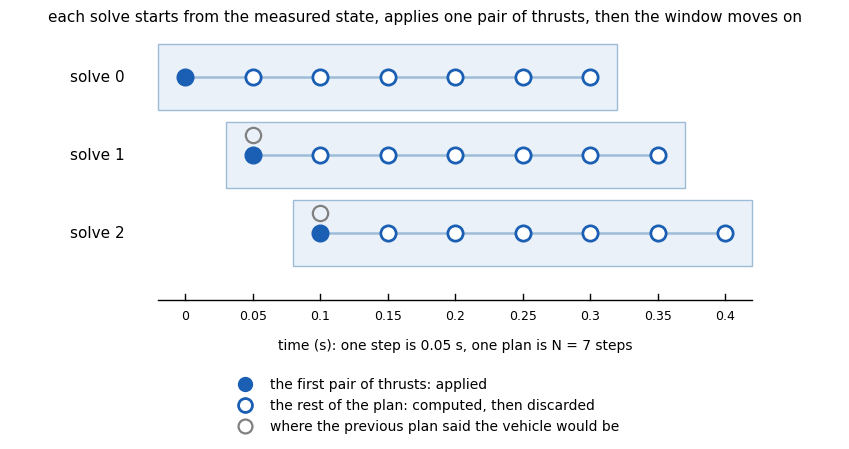

The loop is the same as for the robot. The plant (the system being controlled) is MuJoCo's model of the X2, simulated every 10 ms. The orange box is what MuJoCo can add that the prediction model leaves out: air resistance, when it is switched on.

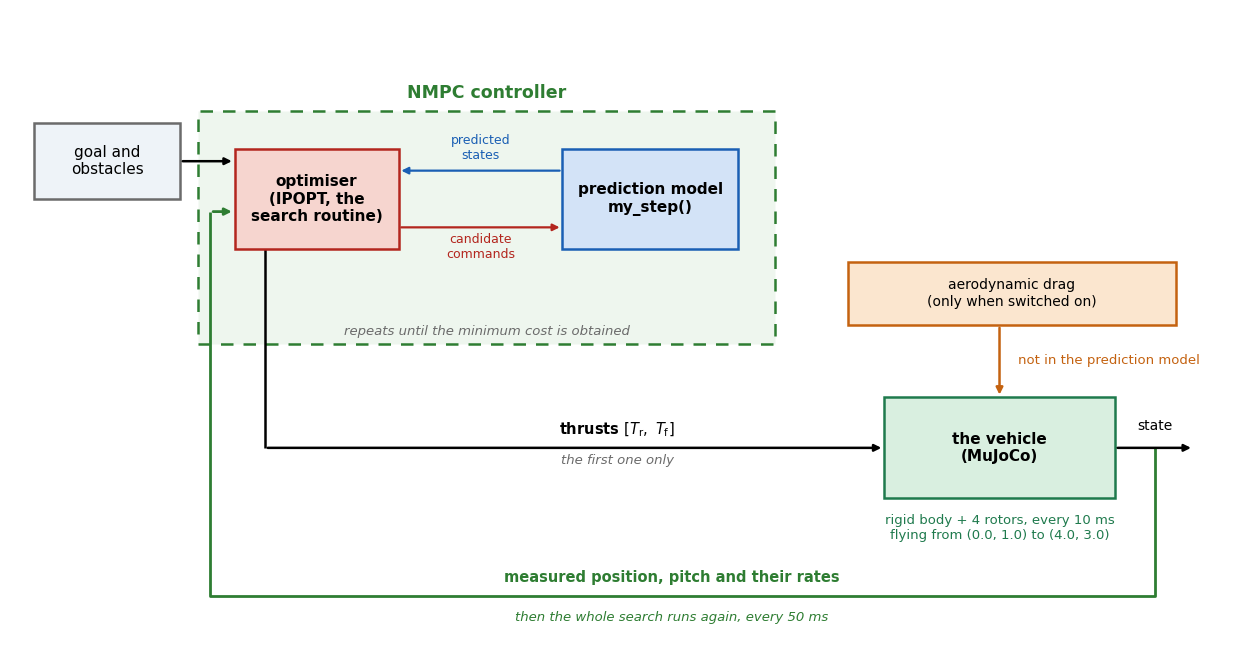

## **4. Building the parts**

| part of the problem | code | who writes it |
| --- | --- | --- |
| the equations of motion | `my_f` | you, Task 1 |
| $\ell^{\text{state}}$, $\ell$ and $V_f$ | `my_state_cost`, `my_stage_cost`, `my_terminal_cost` | you, Task 2 |
| $F$, the predicted states, $J$, the keep-out constraint | `my_step`, `my_rollout`, `my_total_cost`, `my_obstacle` | given: the same as in the robot notebook, apart from small changes |
| applying the plan | two lines | you, Task 3 |

As before, write the tasks with the functions of CasADi [4] (`ca.sin`, `ca.cos`, `ca.vertcat`, `ca.dot`), because the controller calls them with symbols, not numbers.

### **Task 1: write the equations of motion**

Write `my_f(s, u)`. It returns the **rate of change** of all six states, as a column of six numbers.

$$\frac{\mathrm{d}x}{\mathrm{d}t} = \dot x, \qquad \frac{\mathrm{d}z}{\mathrm{d}t} = \dot z, \qquad \frac{\mathrm{d}\theta}{\mathrm{d}t} = \omega$$
$$\ddot x = \frac{T}{m}\sin\theta, \qquad \ddot z = \frac{T}{m}\cos\theta - g, \qquad \dot\omega = \frac{L\,(T_{\mathrm{r}} - T_{\mathrm{f}})}{I_{yy}}$$

The first line reads: the rate of change of $x$ is the state $\dot x$, and so on.

**What you are given.**

| in code | in the equation |
| --- | --- |
| `s[0]`, `s[1]`, `s[2]` | $x$, $z$, $\theta$ |
| `s[3]`, `s[4]`, `s[5]` | $\dot x$, $\dot z$, $\omega$ |
| `u[0]`, `u[1]` | $T_{\mathrm{r}}$, $T_{\mathrm{f}}$ |
| `T` | $T = T_{\mathrm{r}} + T_{\mathrm{f}}$ |
| `lab.MASS`, `lab.G` | $m$, $g$ |
| `lab.L`, `lab.IYY` | $L$, $I_{yy}$ |

**What to do.** The first three rows are written for you. Fill in the last three.

In [ ]:
def my_f(s, u):
    T = u[0] + u[1]
    return ca.vertcat(
        s[3],
        s[4],
        s[5],
        ...,
        ...,
        ...,
    )


lab.check_f(my_f)

<details>
<summary>Hint</summary>

The pitch is `s[2]`. The two thrusts appear as a **sum** in the first two and as a **difference** in the third.
</details>

<details>
<summary>Solution</summary>

```python
T * ca.sin(s[2]) / lab.MASS,
T * ca.cos(s[2]) / lab.MASS - lab.G,
lab.L * (u[0] - u[1]) / lab.IYY,
```
</details>

The sum lifts the vehicle; the difference turns it.

Equations are a claim about the world. Test yours: integrate them beside MuJoCo through the same 1.5 s manoeuvre, in which the thrust difference rocks the vehicle so that it tilts, speeds up sideways and loses height.

In [ ]:
mj, ours = lab.check_against_mujoco(rhs=lambda s, u: np.array(ca.DM(my_f(s, u))).ravel())

After 1.5 s the positions agree to about 1 cm in 2.3 m, and the pitch and velocities to about 0.0002. From here on, anything odd is the controller's doing.

### **Task 2: write the cost, in three small functions**

**(a) The state cost.** `my_state_cost(e, w)` returns one number:

$$\ell^{\text{state}} = w_p\big(e_0^2 + e_1^2\big) + w_\theta e_2^2 + w_v\big(e_3^2 + e_4^2\big) + w_\omega e_5^2$$

**(b) The cost of one step.** `my_stage_cost(e, du, w)` adds the price of the thrust used:

$$\ell = \ell^{\text{state}}(\mathbf{e}) + w_T\,\lVert \Delta\mathbf{u} \rVert^2$$

**(c) The cost of the last step.** `my_terminal_cost(e, w)`:

$$V_f = w_{\mathrm{term}}\,\ell^{\text{state}}(\mathbf{e}_N)$$

**What you are given.**

| in code | meaning |
| --- | --- |
| `e[0]` to `e[5]` | the six parts of the error |
| `du` | the two thrusts measured **from hover**, $\Delta\mathbf{u}$ |
| `w["pos"]`, `w["ang"]`, `w["vel"]`, `w["rate"]` | $w_p$, $w_\theta$, $w_v$, $w_\omega$ |
| `w["thrust"]`, `w["term"]` | $w_T$, $w_{\mathrm{term}}$ |
| `e[0]**2` | $e_0^2$ |
| `ca.dot(du, du)` | $\lVert \Delta\mathbf{u} \rVert^2$ |

**What to do.**

1. In (a), add the four terms.
2. In (b), call (a) and add the thrust term.
3. In (c), multiply (a) by the terminal weight. There is no thrust term, because no thrust is applied after the last step.

In [ ]:
def my_state_cost(e, w):
    return ...


def my_stage_cost(e, du, w):
    return ...


def my_terminal_cost(e, w):
    return ...


lab.check_state_cost(my_state_cost)
lab.check_stage_cost(my_stage_cost)
lab.check_terminal_cost(my_terminal_cost)

<details>
<summary>Hint</summary>

(a) begins `w["pos"] * (e[0]**2 + e[1]**2) + ...`. (b) is `my_state_cost(e, w)` plus one more term. (c) is one product.
</details>

<details>
<summary>Solution</summary>

```python
def my_state_cost(e, w):
    return (w["pos"] * (e[0]**2 + e[1]**2) + w["ang"] * e[2]**2
            + w["vel"] * (e[3]**2 + e[4]**2) + w["rate"] * e[5]**2)


def my_stage_cost(e, du, w):
    return my_state_cost(e, w) + w["thrust"] * ca.dot(du, du)


def my_terminal_cost(e, w):
    return w["term"] * my_state_cost(e, w)
```
</details>

$w_{\mathrm{term}} = 8$, so where each plan ends counts eight times as much as any single step.

### **Parts written for you**

You do not write the four functions in the next cell: they are supplied. You already wrote the same four in the robot notebook (Tasks 1, 2, 3 and 4 there), so writing them again would teach nothing new. Read them, then run the cell; each check should print **PASS**.

They differ from the robot versions in three small ways:

1. the step uses your `my_f`, so it moves all six states at once;
2. the cost uses the whole six-number error, because the vehicle must arrive level and still;
3. the thrust enters the cost measured from hover.

In [ ]:
def my_step(s, u, dt):
    return s + dt * my_f(s, u)              # one Euler step: rate x time


def my_rollout(s0, U, dt):
    X = [s0]
    for k in range(U.shape[1]):
        X.append(my_step(X[-1], U[:, k], dt))
    return ca.horzcat(*X)                   # 6 rows, N + 1 columns


def my_total_cost(X, U, goal, w):
    N = U.shape[1]
    hover = lab.hover_thrust()
    J = 0
    for k in range(N):
        J = J + my_stage_cost(X[:, k] - goal, U[:, k] - hover, w)
    J = J + my_terminal_cost(X[:, N] - goal, w)
    return J


def my_obstacle(p, centre, radius, margin):
    d = p - ca.DM(centre)
    return ca.dot(d, d) - (radius + margin) ** 2


lab.check_step(my_step)
lab.check_rollout(my_rollout)
lab.check_total_cost(my_total_cost)
lab.check_obstacle(my_obstacle)

### **Explain 2: where did the vehicle's size go?**

The robot's `my_obstacle` added the robot's radius (`R_ROBOT` in the robot library) to the smallest allowed distance. This one adds only the margin. Where is the size of the airframe accounted for, and how much room is left over?

*Your answer:*

<details>
<summary>Answer</summary>

In the margin. The controller treats the vehicle as a point (assumption 8), so the 0.35 m margin must also cover the airframe. The rotor tips reach 0.27 m from the centre, which leaves 0.08 m to spare. [Section 1.4](#scrollTo=section-1-4) drew exactly this.
</details>

## **5. The complete algorithm**

### **5.1 Assembling the parts**

`build` works as in the robot notebook, with four differences.

1. The goal is fixed, so it is a plain number (`ca.DM`) rather than a parameter.
2. The pitch limit and the keep-out constraints start at step 2, for the reason given in [Section 3.3](#scrollTo=section-3-3).
3. The trunk uses the same `my_obstacle` function twice, once for each disc in `lab.TRUNK`, with radius `lab.TRUNK_R`.
4. `opti.set_initial(U, lab.hover_thrust())` starts the very first search from hover thrust, a sensible first guess.

Its first line checks that your tasks are finished, and says which one is not.

In [ ]:
def build(N=20, dt=lab.DT, w=None):
    lab.require_finished(my_f, my_state_cost, my_stage_cost, my_terminal_cost,
                         my_step, my_rollout, my_total_cost, my_obstacle)
    w = w or dict(lab.WEIGHTS)
    opti = ca.Opti()
    U = opti.variable(2, N)
    s0 = opti.parameter(6)
    goal = ca.DM(lab.GOAL)

    X = my_rollout(s0, U, dt)
    opti.minimize(my_total_cost(X, U, goal, w))

    for k in range(2, N + 1):          # steps 0 and 1 are fixed by the measurement
        opti.subject_to(my_obstacle(X[:2, k], lab.OBS_C, lab.OBS_R,
                                    lab.CLEAR) >= 0)
        for centre in lab.TRUNK:                  # the trunk: two small discs
            opti.subject_to(my_obstacle(X[:2, k], centre, lab.TRUNK_R,
                                        lab.CLEAR) >= 0)
        opti.subject_to(opti.bounded(-lab.PITCH_MAX, X[2, k], lab.PITCH_MAX))
    opti.subject_to(opti.bounded(0, ca.vec(U), lab.TMAX_PAIR))

    opti.set_initial(U, lab.hover_thrust())
    opti.solver("ipopt", {"print_time": 0, "ipopt.print_level": 0,
                          "ipopt.sb": "yes"})
    return opti, X, U, s0


print("the problem has %d thrusts to choose" % (2 * 20))

### **Task 3: close the loop**

The same two lines as the robot's Task 5, for the vehicle. There is no hint this time.

| in code | meaning |
| --- | --- |
| `Uopt` | the plan: 2 rows, $N$ columns |
| `s` | where the vehicle is now, six numbers |
| `lab.DT` | the time step, 0.05 s |

As in the robot notebook, the vehicle in this loop is the model itself: your `my_step` moves it.

One line differs from the robot's loop, and it is written for you: the last one. The next search starts from the rest of this plan, moved one step earlier, because one step of it has now been used. (The last column is repeated to fill the gap.) Starting the search there, rather than from the unchanged plan, keeps IPOPT from failing near the trunk.

In [ ]:
opti, X, U, ps = build()

s = lab.START.copy()
path = [s.copy()]

for step in range(120):
    opti.set_value(ps, s)
    sol = opti.solve()
    Uopt = np.array(sol.value(U))

    u = ...
    s = ...
    lab.stop_unless(u is not ... and s is not ...,
                    "write the two lines for u and s above, then run this cell again.")

    path.append(np.array(s).ravel())
    opti.set_initial(U, np.hstack([Uopt[:, 1:], Uopt[:, -1:]]))   # shift by one step

path = np.array(path)
lab.check_loop(path)

<details>
<summary>Solution</summary>

```python
u = Uopt[:, 0]
s = np.array(my_step(s, u, lab.DT)).ravel()
```
</details>

### **5.2 The result**

In [ ]:
lab.stop_unless(lab.is_path(globals().get("path")),
                "finish Task 3 first, then run this cell again.")

fig, ax = plt.subplots(figsize=(6.6, 5.0))
lab.draw_trunk(ax)
ax.add_patch(plt.Circle(lab.OBS_C, lab.OBS_R, color=lab.OBS_FC))
ax.add_patch(plt.Circle(lab.OBS_C, lab.OBS_R + lab.CLEAR, fc="none",
                        ec="green", ls=(0, (2, 3)), lw=1.6))
ax.plot(path[:, 0], path[:, 1], lw=2.5, color="blue",
        label="your controller")
ax.plot(lab.START[0], lab.START[1], "o", color="black", ms=8)
ax.plot(lab.GOAL[0], lab.GOAL[1], "*", color="green", ms=17)
ax.set_xlabel("x (m)"); ax.set_ylabel("z (m)")
ax.set_aspect("equal"); ax.grid(alpha=0.25); ax.legend(fontsize=9)
plt.show()

**That is nonlinear model predictive control, for an aircraft.** You wrote the model, the cost and the loop; the search is IPOPT's.

The vehicle climbs and passes **over** the obstruction, riding exactly along its keep-out ring. The check also confirms that it never entered the trunk's rings.

From here the notebook calls `lab.run(build)`. That is the loop you have just written, with the vehicle, the recording and a stopping test around it: it runs **your** `build`, so the plans are yours. The difference is the vehicle: `lab.run` flies MuJoCo's X2, not the model. Every run from [Section 6](#scrollTo=section-6) on is on MuJoCo.

`lab.run` prints a report. Two lines need a word:

1. **solver gave up**: how many times IPOPT stopped without meeting its own test for a best allowed answer. The controller then uses IPOPT's last attempt, as a real controller must, since a new command is due every 50 ms. In the runs here it should read 0.
2. **computing time**: how long each solve took. Each solve must finish within the 50 ms step. The typical solve here is well inside it; on a slower computer the slowest may not be. A real controller must handle that, for example by using the rest of the previous plan when a solve runs late.

## **6. On the simulated vehicle**

### **6.1 The plant**

In your own loop ([Section 5](#scrollTo=section-5)) the plant, the system being controlled, was the model. `lab.run` flies MuJoCo's X2 instead: a rigid body with four rotors, simulated every 10 ms, while the controller still predicts with one Euler step every 50 ms.

In [ ]:
log = lab.run(build)

Compare with your model-only flight, which rode exactly on the ring. On MuJoCo the vehicle arrives a little later (about 2.05 s against 1.95 s) and cuts about 2 cm inside the keep-out ring, because the Euler prediction is not exact. Its rotor tips still clear the obstruction by about 6 cm. That is what the margin is for; the feedback does the rest.

### **6.2 Watching the flight**

The dots are the current plan.

In [ ]:
lab.stop_unless("log" in globals(), "run the cell above first, then run this cell again.")

lab.animate_line(log)

Watch the vehicle **lean into** the direction it wants to travel before it moves, then lean back to stop. No line of code says "lean first": it follows from $\ddot x = (T/m)\sin\theta$, which you wrote in Task 1.

The same flight, inside MuJoCo itself.

In [ ]:
lab.stop_unless("log" in globals(), "run the cell above first, then run this cell again.")

lab.animate_mujoco(log)

## **7. The effect of the horizon**

$N$ is how many steps a plan contains, each 0.05 s long. **Try $N = 20$, then $10$, then $5$.**

In [ ]:
log = lab.run(build, N=20)        # EDIT: try 10, then 5
lab.plot_run(log)

1. With $N = 20$ (1 s ahead) the vehicle reaches the goal after about 2.05 s.
2. With $N = 10$ (0.5 s ahead) it still arrives, but later, after about 2.6 s.
3. With $N = 5$ (0.25 s ahead) it creeps, and after the 6 s run it is still 0.55 m short. Tilting costs thrust now, but the speed that tilting buys mostly pays off after the end of such a short window, so each plan tilts only a little.

So the horizon must be long enough for the benefit of each manoeuvre to fall inside it, and no longer than the computer can solve in time.

## **8. In a future workshop**

This workshop ends here. A future workshop will look at:

1. **The thrust weight and the pitch limit.** How the price on thrust and the tilt limit change the speed and the route.
2. **One shot against re-solving.** Planning the whole flight in one solve, flying it with nothing measured, and seeing what air resistance (drag) does, compared with re-solving at every step.
3. **Feedback against accuracy.** Why a rougher model with feedback can beat an accurate plan without it.

## **9. References**

1. Chen, H., Lan, Y., Fritz, B. K., Hoffmann, W. C. and Liu, S. (2021) Review of agricultural spraying technologies for plant protection using unmanned aerial vehicle (UAV). *International Journal of Agricultural and Biological Engineering*, 14(1), pp. 38-49.
2. Mahony, R., Kumar, V. and Corke, P. (2012) Multirotor aerial vehicles: modeling, estimation, and control of quadrotor. *IEEE Robotics and Automation Magazine*, 19(3), pp. 20-32.
3. Rawlings, J. B., Mayne, D. Q. and Diehl, M. M. (2017) *Model Predictive Control: Theory, Computation, and Design*. 2nd edn. Madison, WI: Nob Hill Publishing.
4. Andersson, J. A. E., Gillis, J., Horn, G., Rawlings, J. B. and Diehl, M. (2019) CasADi: a software framework for nonlinear optimization and optimal control. *Mathematical Programming Computation*, 11(1), pp. 1-36.
5. Todorov, E., Erez, T. and Tassa, Y. (2012) MuJoCo: a physics engine for model-based control. *IEEE/RSJ International Conference on Intelligent Robots and Systems*, pp. 5026-5033.
6. Zakka, K. et al. (2022) *MuJoCo Menagerie: a collection of high-quality simulation models for MuJoCo*. Available at: https://github.com/google-deepmind/mujoco_menagerie